In [3]:
import pysam
from collections import Counter
import matplotlib.pyplot as plt

In [4]:
bwa = pysam.AlignmentFile("../results/arab_bwa_default_mapping/bam/ampDAP_DEL1.bam")
bt = pysam.AlignmentFile("../results/arab_bowtie2_default_mapping/bam/ampDAP_DEL1.bam")


## Total Reads

In [5]:
bwa_total = bwa.count(until_eof=True)
bt_total = bt.count(until_eof=True)

print(f"BWA-MEM: {bwa_total:,}")
print(f"Bowtie2: {bt_total:,}")

bwa.reset()
bt.reset()

BWA-MEM: 2,372,219
Bowtie2: 2,223,881


0

In [6]:
bwa_mapq = Counter()
bt_mapq = Counter()

for read in bwa.fetch(until_eof=True):
    if not read.is_unmapped and not read.is_secondary and not read.is_supplementary:
        bwa_mapq[read.mapping_quality] += 1

for read in bt.fetch(until_eof=True):
    if not read.is_unmapped and not read.is_secondary and not read.is_supplementary:
        bt_mapq[read.mapping_quality] += 1

bwa.reset()
bt.reset()

print("BWA-MEM MAPQ distribution:")
for q in sorted(bwa_mapq):
    print(f"  MAPQ {q}: {bwa_mapq[q]:,}")

print("\nBowtie2 MAPQ distribution:")
for q in sorted(bt_mapq):
    print(f"  MAPQ {q}: {bt_mapq[q]:,}")

BWA-MEM MAPQ distribution:
  MAPQ 20: 2,820
  MAPQ 21: 1,831
  MAPQ 22: 1,788
  MAPQ 23: 2,588
  MAPQ 24: 2,378
  MAPQ 25: 4,600
  MAPQ 26: 15,188
  MAPQ 27: 8,132
  MAPQ 28: 4,525
  MAPQ 29: 3,800
  MAPQ 30: 3,414
  MAPQ 31: 4,828
  MAPQ 32: 3,192
  MAPQ 33: 5,248
  MAPQ 34: 2,551
  MAPQ 35: 2,563
  MAPQ 36: 2,747
  MAPQ 37: 2,503
  MAPQ 38: 10,193
  MAPQ 39: 3,718
  MAPQ 40: 2,563
  MAPQ 41: 3,829
  MAPQ 42: 2,651
  MAPQ 43: 4,067
  MAPQ 44: 2,683
  MAPQ 45: 2,268
  MAPQ 46: 4,089
  MAPQ 47: 2,511
  MAPQ 48: 3,285
  MAPQ 49: 4,088
  MAPQ 50: 1,923
  MAPQ 51: 8,714
  MAPQ 52: 2,888
  MAPQ 53: 2,191
  MAPQ 54: 5,087
  MAPQ 55: 2,208
  MAPQ 56: 4,377
  MAPQ 57: 2,126
  MAPQ 58: 1,988
  MAPQ 59: 4,486
  MAPQ 60: 2,210,369

Bowtie2 MAPQ distribution:
  MAPQ 21: 4,056
  MAPQ 22: 5,815
  MAPQ 23: 65,114
  MAPQ 24: 45,511
  MAPQ 25: 4,992
  MAPQ 26: 5,528
  MAPQ 27: 3,506
  MAPQ 30: 46,948
  MAPQ 31: 26,586
  MAPQ 32: 26,208
  MAPQ 33: 1,618
  MAPQ 34: 23,258
  MAPQ 35: 29,477
  MAPQ 36: 21,

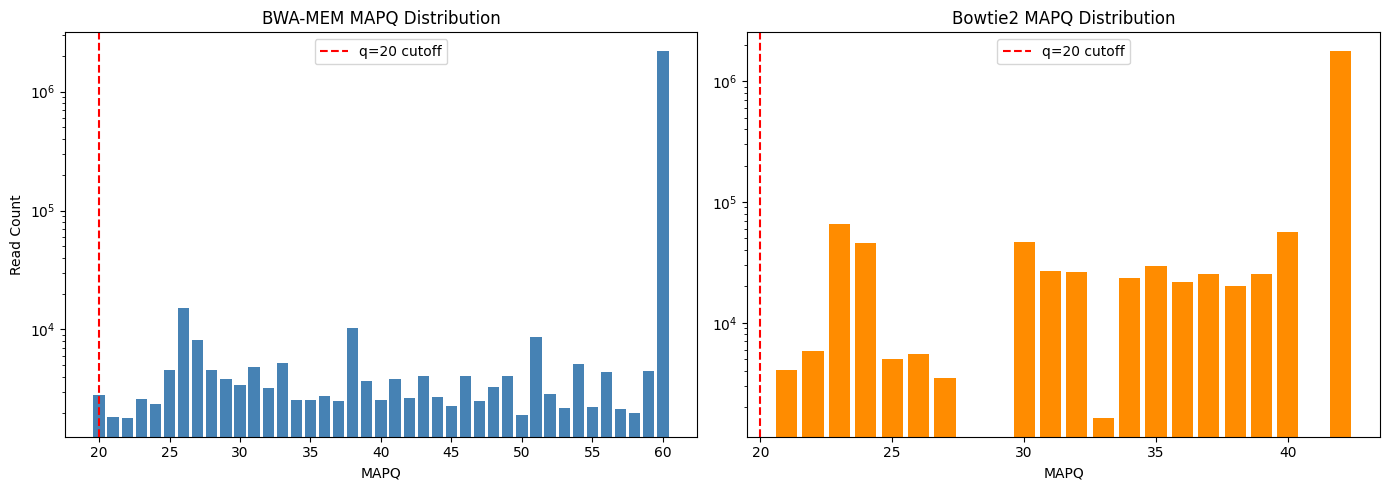

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

qs = sorted(bwa_mapq.keys())
ax1.bar(qs, [bwa_mapq[q] for q in qs], color="steelblue")
ax1.set_title("BWA-MEM MAPQ Distribution")
ax1.set_xlabel("MAPQ")
ax1.set_ylabel("Read Count")
ax1.set_yscale("log")
ax1.axvline(x=20, color="red", linestyle="--", label="q=20 cutoff")
ax1.legend()

qs = sorted(bt_mapq.keys())
ax2.bar(qs, [bt_mapq[q] for q in qs], color="darkorange")
ax2.set_title("Bowtie2 MAPQ Distribution")
ax2.set_xlabel("MAPQ")
ax2.set_yscale("log")
ax2.axvline(x=20, color="red", linestyle="--", label="q=20 cutoff")
ax2.legend()

plt.tight_layout()
plt.show()

In [8]:
bwa_clip_counts = {"clipped": 0, "not_clipped": 0}
bt_clip_counts = {"clipped": 0, "not_clipped": 0}
bwa_clip_bases = []
bt_clip_bases = []

for read in bwa.fetch(until_eof=True):
    if read.is_unmapped or read.is_secondary or read.is_supplementary:
        continue
    if read.cigartuples is None:
        continue
    clip = sum(length for op, length in read.cigartuples if op == 4)
    if clip > 0:
        bwa_clip_counts["clipped"] += 1
        bwa_clip_bases.append(clip)
    else:
        bwa_clip_counts["not_clipped"] += 1

for read in bt.fetch(until_eof=True):
    if read.is_unmapped or read.is_secondary or read.is_supplementary:
        continue
    if read.cigartuples is None:
        continue
    clip = sum(length for op, length in read.cigartuples if op == 4)
    if clip > 0:
        bt_clip_counts["clipped"] += 1
        bt_clip_bases.append(clip)
    else:
        bt_clip_counts["not_clipped"] += 1

for label, counts in [("BWA-MEM", bwa_clip_counts), ("Bowtie2", bt_clip_counts)]:
    total = counts["clipped"] + counts["not_clipped"]
    print(f"{label}: {counts['clipped']:,} clipped / {total:,} primary ({counts['clipped']/total*100:.1f}%)")

bwa.reset()
bt.reset()

BWA-MEM: 381,008 clipped / 2,366,998 primary (16.1%)
Bowtie2: 0 clipped / 2,223,881 primary (0.0%)


0

In [9]:
bwa_score_diff = []
bt_score_diff = []

for read in bwa.fetch(until_eof=True):
    if read.is_unmapped or read.is_secondary or read.is_supplementary:
        continue
    AS = read.get_tag("AS") if read.has_tag("AS") else None
    XS = read.get_tag("XS") if read.has_tag("XS") else None
    if AS is not None and XS is not None:
        bwa_score_diff.append(AS - XS)

for read in bt.fetch(until_eof=True):
    if read.is_unmapped or read.is_secondary or read.is_supplementary:
        continue
    AS = read.get_tag("AS") if read.has_tag("AS") else None
    XS = read.get_tag("XS") if read.has_tag("XS") else None
    if AS is not None and XS is not None:
        bt_score_diff.append(AS - XS)

bwa.reset()
bt.reset()

0

In [10]:
bwa_clipped_mapq = []
bwa_unclipped_mapq = []

for read in bwa.fetch(until_eof=True):
    if read.is_unmapped or read.is_secondary or read.is_supplementary:
        continue
    if read.cigartuples is None:
        continue
    has_clip = any(op == 4 for op, _ in read.cigartuples)
    if has_clip:
        bwa_clipped_mapq.append(read.mapping_quality)
    else:
        bwa_unclipped_mapq.append(read.mapping_quality)

bwa.reset()

0

In [11]:
clipped = Counter(bwa_clipped_mapq)
unclipped = Counter(bwa_unclipped_mapq)

clipped_pass = sum(1 for q in bwa_clipped_mapq if q >= 20)
unclipped_pass = sum(1 for q in bwa_unclipped_mapq if q >= 20)

print(f"Clipped reads:   {len(bwa_clipped_mapq):,} total, {clipped_pass:,} pass q>=20 ({clipped_pass/len(bwa_clipped_mapq)*100:.1f}%)")
print(f"Unclipped reads: {len(bwa_unclipped_mapq):,} total, {unclipped_pass:,} pass q>=20 ({unclipped_pass/len(bwa_unclipped_mapq)*100:.1f}%)")

Clipped reads:   381,008 total, 381,008 pass q>=20 (100.0%)
Unclipped reads: 1,985,990 total, 1,985,990 pass q>=20 (100.0%)


In [12]:
total_input = 3518295  # from the Bowtie2 log — same FASTQ goes to both aligners

bwa_surviving = bwa.count(until_eof=True)
bt_surviving = bt.count(until_eof=True)

print(f"Input reads:        {total_input:,}")
print(f"BWA-MEM final BAM:  {bwa_surviving:,} ({bwa_surviving/total_input*100:.1f}%)")
print(f"Bowtie2 final BAM:  {bt_surviving:,} ({bt_surviving/total_input*100:.1f}%)")
print(f"Difference:         {bt_surviving - bwa_surviving:+,}")

bwa.reset()
bt.reset()

Input reads:        3,518,295
BWA-MEM final BAM:  2,372,219 (67.4%)
Bowtie2 final BAM:  2,223,881 (63.2%)
Difference:         -148,338


0